# 23CO315 - Piyusha Supe
**NLP - Practical 1**

**Perform tokenization (Whitespace, Punctuation-based, Treebank, Tweet, MWE) using NLTK
library. Use porter stemmer and snowball stemmer for stemming. Use any technique for
lemmatization.
Input / Dataset –use any sample sentence**

In [2]:

# ============================================
# NLP PREPROCESSING USING NLTK
# ============================================

import nltk
import string
from nltk.tokenize import (
    word_tokenize,
    WhitespaceTokenizer,
    TreebankWordTokenizer,
    TweetTokenizer,
    MWETokenizer
)
from nltk.stem import PorterStemmer, SnowballStemmer
from nltk.stem import WordNetLemmatizer


In [14]:
# --------------------------------------------
# DOWNLOAD REQUIRED DATA (Run once)
# --------------------------------------------
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('averaged_perceptron_tagger')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

In [10]:
# --------------------------------------------
# SAMPLE INPUT TEXT
# --------------------------------------------
text = """The 52-hertz whale is one of the most fascinating and mysterious creatures ever detected in the oceans, often
referred to as the “loneliest whale in the world.” This whale was first identified in 1989 by researchers from the Woods Hole Oceanographic
Institution while analyzing underwater acoustic data collected by the U.S. Navy. What made this whale extraordinary was the frequency of its
 call—52 hertz—which is much higher than the typical vocalizations of other large whale species. For example, blue whale usually communicate at
 frequencies between 10 and 39 hertz, while fin whale calls are typically around 20 hertz. Because sound travels differently underwater, whales
 rely heavily on low-frequency calls to communicate across vast distances, sometimes hundreds of kilometers. The 52-hertz whale’s unusual pitch
 suggests that other whales may not be able to hear or recognize its calls,
which is why it has been popularly described as “lonely,” though this interpretation is more poetic than scientifically confirmed.
Over the years, the whale has been tracked moving across the North Pacific Ocean, following migration patterns somewhat similar to other
baleen whales, yet always singing at its unique frequency. Scientists are still unsure what species it belongs to; some hypothesize it
could be a hybrid between different whale species, while others think it might be an individual with a physical anomaly that affects its
vocalization system. Despite its uniqueness, the whale does not appear to be distressed—it continues to travel, feed, and vocalize consistently,
 suggesting it is surviving normally. The idea of its loneliness has captured global imagination, inspiring documentaries, music, and even films,
  turning the 52-hertz whale into a symbol of isolation and individuality. Scientifically, however, it remains an open question whether the whale
  is truly isolated or simply communicating in ways we do not yet fully understand, reminding us how much of the ocean—and the lives within it—still
   remains a mystery."""

print("\n================ ORIGINAL TEXT ================\n")
print(text)



================ ORIGINAL TEXT ================

The 52-hertz whale is one of the most fascinating and mysterious creatures ever detected in the oceans, often 
referred to as the “loneliest whale in the world.” This whale was first identified in 1989 by researchers from the Woods Hole Oceanographic 
Institution while analyzing underwater acoustic data collected by the U.S. Navy. What made this whale extraordinary was the frequency of its
 call—52 hertz—which is much higher than the typical vocalizations of other large whale species. For example, blue whale usually communicate at 
 frequencies between 10 and 39 hertz, while fin whale calls are typically around 20 hertz. Because sound travels differently underwater, whales 
 rely heavily on low-frequency calls to communicate across vast distances, sometimes hundreds of kilometers. The 52-hertz whale’s unusual pitch 
 suggests that other whales may not be able to hear or recognize its calls, 
which is why it has been popularly described 

In [11]:
# ============================================
# 1. TOKENIZATION FUNCTIONS
# ============================================

def whitespace_tokenization(text):
    tokenizer = WhitespaceTokenizer()
    return tokenizer.tokenize(text)

def punctuation_tokenization(text):
    tokens = []
    for word in text.split():
        clean_word = word.strip(string.punctuation)
        if clean_word:
            tokens.append(clean_word)
    return tokens

def treebank_tokenization(text):
    tokenizer = TreebankWordTokenizer()
    return tokenizer.tokenize(text)

def tweet_tokenization(text):
    tokenizer = TweetTokenizer()
    return tokenizer.tokenize(text)

def mwe_tokenization(text):
    # Define Multi-Word Expressions
    mwe = MWETokenizer([
        ('Natural', 'Language'),
        ('New', 'York')
    ])
    tokens = word_tokenize(text)
    return mwe.tokenize(tokens)

# --------------------------------------------
# RUN TOKENIZATION
# --------------------------------------------

print("\n================ TOKENIZATION ================\n")

ws_tokens = whitespace_tokenization(text)
print("1. Whitespace Tokens:\n", ws_tokens)

punct_tokens = punctuation_tokenization(text)
print("\n2. Punctuation-based Tokens:\n", punct_tokens)

tree_tokens = treebank_tokenization(text)
print("\n3. Treebank Tokens:\n", tree_tokens)

tweet_tokens = tweet_tokenization(text)
print("\n4. Tweet Tokens:\n", tweet_tokens)

mwe_tokens = mwe_tokenization(text)
print("\n5. MWE Tokens:\n", mwe_tokens)



================ TOKENIZATION ================

1. Whitespace Tokens:
 ['The', '52-hertz', 'whale', 'is', 'one', 'of', 'the', 'most', 'fascinating', 'and', 'mysterious', 'creatures', 'ever', 'detected', 'in', 'the', 'oceans,', 'often', 'referred', 'to', 'as', 'the', '“loneliest', 'whale', 'in', 'the', 'world.”', 'This', 'whale', 'was', 'first', 'identified', 'in', '1989', 'by', 'researchers', 'from', 'the', 'Woods', 'Hole', 'Oceanographic', 'Institution', 'while', 'analyzing', 'underwater', 'acoustic', 'data', 'collected', 'by', 'the', 'U.S.', 'Navy.', 'What', 'made', 'this', 'whale', 'extraordinary', 'was', 'the', 'frequency', 'of', 'its', 'call—52', 'hertz—which', 'is', 'much', 'higher', 'than', 'the', 'typical', 'vocalizations', 'of', 'other', 'large', 'whale', 'species.', 'For', 'example,', 'blue', 'whale', 'usually', 'communicate', 'at', 'frequencies', 'between', '10', 'and', '39', 'hertz,', 'while', 'fin', 'whale', 'calls', 'are', 'typically', 'around', '20', 'hertz.', 'Because'

In [12]:

# ============================================
# 2. STEMMING
# ============================================

def porter_stemming(tokens):
    stemmer = PorterStemmer()
    return [stemmer.stem(word) for word in tokens]

def snowball_stemming(tokens):
    stemmer = SnowballStemmer("english")
    return [stemmer.stem(word) for word in tokens]

print("\n================ STEMMING ================\n")

porter_result = porter_stemming(tree_tokens)
print("6. Porter Stemmer Output:\n", porter_result)

snowball_result = snowball_stemming(tree_tokens)
print("\n7. Snowball Stemmer Output:\n", snowball_result)



================ STEMMING ================

6. Porter Stemmer Output:
 ['the', '52-hertz', 'whale', 'is', 'one', 'of', 'the', 'most', 'fascin', 'and', 'mysteri', 'creatur', 'ever', 'detect', 'in', 'the', 'ocean', ',', 'often', 'refer', 'to', 'as', 'the', '“loneliest', 'whale', 'in', 'the', 'world.”', 'thi', 'whale', 'wa', 'first', 'identifi', 'in', '1989', 'by', 'research', 'from', 'the', 'wood', 'hole', 'oceanograph', 'institut', 'while', 'analyz', 'underwat', 'acoust', 'data', 'collect', 'by', 'the', 'u.s.', 'navy.', 'what', 'made', 'thi', 'whale', 'extraordinari', 'wa', 'the', 'frequenc', 'of', 'it', 'call—52', 'hertz—which', 'is', 'much', 'higher', 'than', 'the', 'typic', 'vocal', 'of', 'other', 'larg', 'whale', 'species.', 'for', 'exampl', ',', 'blue', 'whale', 'usual', 'commun', 'at', 'frequenc', 'between', '10', 'and', '39', 'hertz', ',', 'while', 'fin', 'whale', 'call', 'are', 'typic', 'around', '20', 'hertz.', 'becaus', 'sound', 'travel', 'differ', 'underwat', ',', 'whale', '

In [15]:

# ============================================
# 3. LEMMATIZATION
# ============================================

lemmatizer = WordNetLemmatizer()

def simple_lemmatization(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]

# POS tagging helper
def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return 'a'  # adjective
    elif tag.startswith('V'):
        return 'v'  # verb
    elif tag.startswith('N'):
        return 'n'  # noun
    elif tag.startswith('R'):
        return 'r'  # adverb
    else:
        return 'n'

def pos_lemmatization(tokens):
    pos_tags = nltk.pos_tag(tokens)
    return [
        lemmatizer.lemmatize(word, get_wordnet_pos(tag))
        for word, tag in pos_tags
    ]

print("\n================ LEMMATIZATION ================\n")

simple_lemmas = simple_lemmatization(tree_tokens)
print("8. Simple Lemmatization:\n", simple_lemmas)

pos_lemmas = pos_lemmatization(tree_tokens)
print("\n9. POS-based Lemmatization:\n", pos_lemmas)




================ LEMMATIZATION ================

8. Simple Lemmatization:
 ['The', '52-hertz', 'whale', 'is', 'one', 'of', 'the', 'most', 'fascinating', 'and', 'mysterious', 'creature', 'ever', 'detected', 'in', 'the', 'ocean', ',', 'often', 'referred', 'to', 'a', 'the', '“loneliest', 'whale', 'in', 'the', 'world.”', 'This', 'whale', 'wa', 'first', 'identified', 'in', '1989', 'by', 'researcher', 'from', 'the', 'Woods', 'Hole', 'Oceanographic', 'Institution', 'while', 'analyzing', 'underwater', 'acoustic', 'data', 'collected', 'by', 'the', 'U.S.', 'Navy.', 'What', 'made', 'this', 'whale', 'extraordinary', 'wa', 'the', 'frequency', 'of', 'it', 'call—52', 'hertz—which', 'is', 'much', 'higher', 'than', 'the', 'typical', 'vocalization', 'of', 'other', 'large', 'whale', 'species.', 'For', 'example', ',', 'blue', 'whale', 'usually', 'communicate', 'at', 'frequency', 'between', '10', 'and', '39', 'hertz', ',', 'while', 'fin', 'whale', 'call', 'are', 'typically', 'around', '20', 'hertz.', 'Bec

In [16]:

# ============================================
# 4. COMPARISON TABLE
# ============================================

print("\n================ COMPARISON TABLE ================\n")

print("{:<15} {:<15} {:<15} {:<15}".format(
    "Original", "Porter", "Snowball", "Lemma"
))

for i in range(min(len(tree_tokens), 10)):  # limit for readability
    print("{:<15} {:<15} {:<15} {:<15}".format(
        tree_tokens[i],
        porter_result[i],
        snowball_result[i],
        pos_lemmas[i]
    ))




================ COMPARISON TABLE ================

Original        Porter          Snowball        Lemma          
The             the             the             The            
52-hertz        52-hertz        52-hertz        52-hertz       
whale           whale           whale           whale          
is              is              is              be             
one             one             one             one            
of              of              of              of             
the             the             the             the            
most            most            most            most           
fascinating     fascin          fascin          fascinating    
and             and             and             and            



================ SUMMARY ================

Total Tokens (Treebank): 335
Unique Tokens: 213
After Stemming (Porter): 194
After Lemmatization: 201

PROCESS COMPLETED SUCCESSFULLY ✅


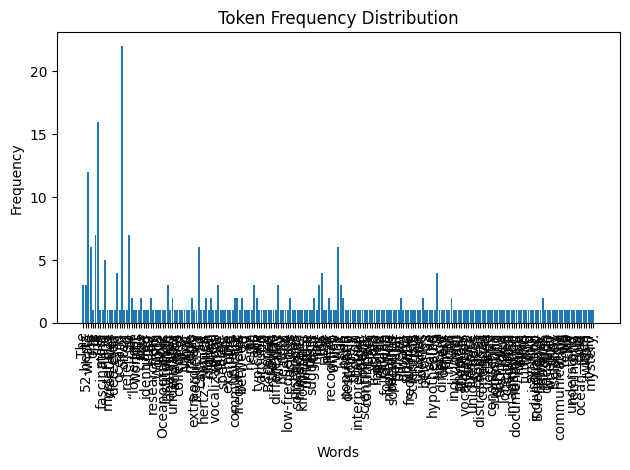

In [17]:

# ============================================
# 5. SUMMARY
# ============================================

print("\n================ SUMMARY ================\n")

print(f"Total Tokens (Treebank): {len(tree_tokens)}")
print(f"Unique Tokens: {len(set(tree_tokens))}")
print(f"After Stemming (Porter): {len(set(porter_result))}")
print(f"After Lemmatization: {len(set(pos_lemmas))}")

print("\nPROCESS COMPLETED SUCCESSFULLY ✅")


import matplotlib.pyplot as plt
from collections import Counter

# ============================================
# 1. TOKEN FREQUENCY DISTRIBUTION
# ============================================

freq_dist = Counter(tree_tokens)

words = list(freq_dist.keys())
counts = list(freq_dist.values())

plt.figure()
plt.bar(words, counts)
plt.xticks(rotation=90)
plt.title("Token Frequency Distribution")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()



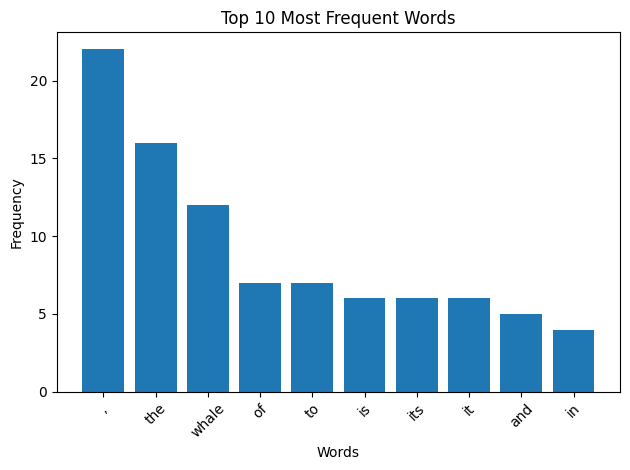

In [18]:

# ============================================
# 2. TOP 10 MOST COMMON WORDS
# ============================================

top_words = freq_dist.most_common(10)
top_w, top_c = zip(*top_words)

plt.figure()
plt.bar(top_w, top_c)
plt.title("Top 10 Most Frequent Words")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



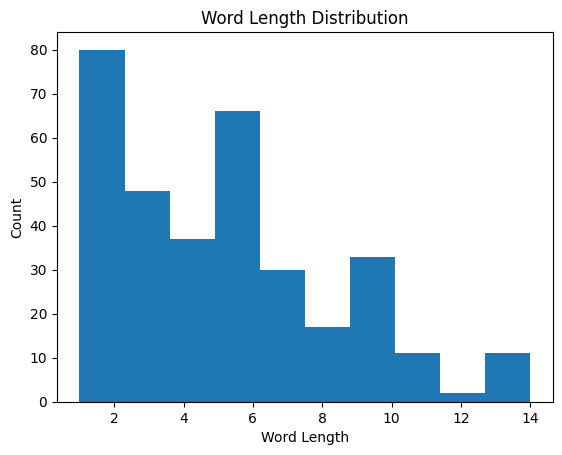

In [19]:

# ============================================
# 3. WORD LENGTH DISTRIBUTION
# ============================================

word_lengths = [len(word) for word in tree_tokens]

plt.figure()
plt.hist(word_lengths, bins=10)
plt.title("Word Length Distribution")
plt.xlabel("Word Length")
plt.ylabel("Count")
plt.show()



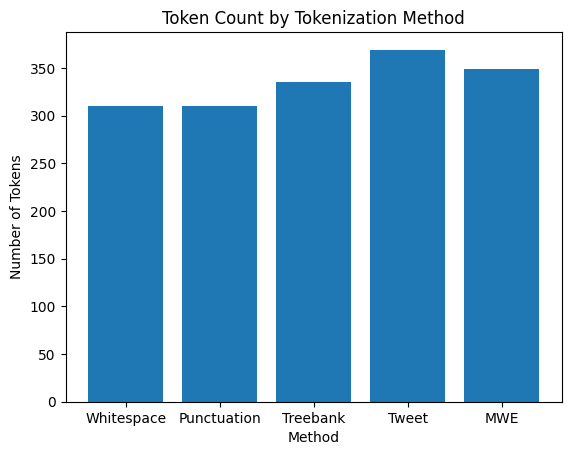

In [20]:

# ============================================
# 4. TOKEN COUNT COMPARISON (Different Methods)
# ============================================

methods = ['Whitespace', 'Punctuation', 'Treebank', 'Tweet', 'MWE']
counts = [
    len(ws_tokens),
    len(punct_tokens),
    len(tree_tokens),
    len(tweet_tokens),
    len(mwe_tokens)
]

plt.figure()
plt.bar(methods, counts)
plt.title("Token Count by Tokenization Method")
plt.xlabel("Method")
plt.ylabel("Number of Tokens")
plt.show()



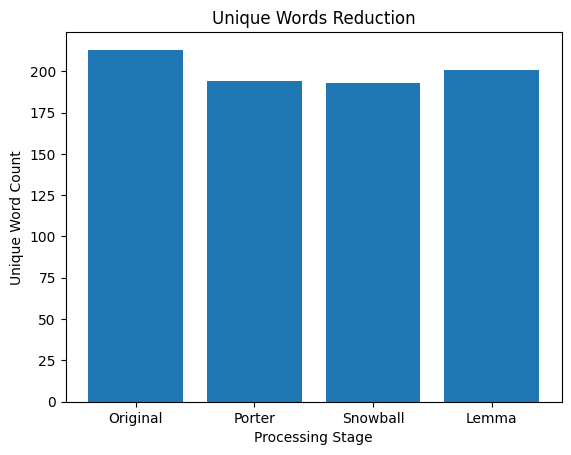

In [21]:

# ============================================
# 5. UNIQUE WORD REDUCTION
# ============================================

original_unique = len(set(tree_tokens))
porter_unique = len(set(porter_result))
snowball_unique = len(set(snowball_result))
lemma_unique = len(set(pos_lemmas))

labels = ['Original', 'Porter', 'Snowball', 'Lemma']
values = [original_unique, porter_unique, snowball_unique, lemma_unique]

plt.figure()
plt.bar(labels, values)
plt.title("Unique Words Reduction")
plt.xlabel("Processing Stage")
plt.ylabel("Unique Word Count")
plt.show()



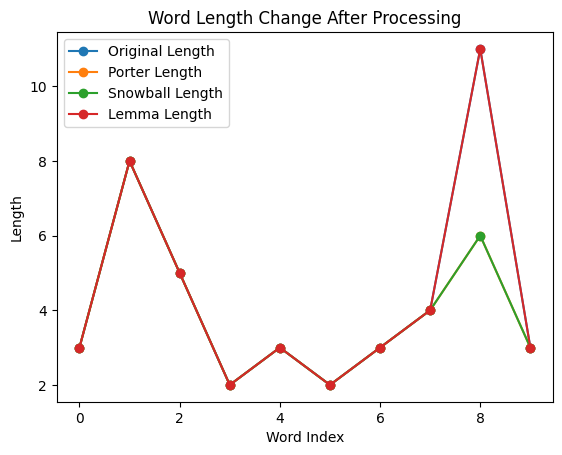


VISUALIZATION COMPLETED ✅


In [22]:

# ============================================
# 6. STEMMING vs LEMMATIZATION COMPARISON
# ============================================

sample_words = tree_tokens[:10]

porter_sample = porter_result[:10]
snowball_sample = snowball_result[:10]
lemma_sample = pos_lemmas[:10]

x = range(len(sample_words))

plt.figure()
plt.plot(x, [len(w) for w in sample_words], marker='o', label="Original Length")
plt.plot(x, [len(w) for w in porter_sample], marker='o', label="Porter Length")
plt.plot(x, [len(w) for w in snowball_sample], marker='o', label="Snowball Length")
plt.plot(x, [len(w) for w in lemma_sample], marker='o', label="Lemma Length")

plt.title("Word Length Change After Processing")
plt.xlabel("Word Index")
plt.ylabel("Length")
plt.legend()
plt.show()

print("\nVISUALIZATION COMPLETED ✅")